In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [3]:
import torch
import numpy as np
import panel as pn
from IPython.display import display, clear_output
pn.extension()

from bokeh.resources import INLINE
import matplotlib.pyplot as plt


In [4]:
from polarizedpotentialparticles.configs import Config, ParticleConfig, SimulationConfig, LossConfig
from polarizedpotentialparticles.trainer import Trainer
from polarizedpotentialparticles.displays import Displayer
from polarizedpotentialparticles.scripts.generate_dashboard_manifest import build_manifest

In [5]:
p_cfg = ParticleConfig()
t_cfg = SimulationConfig()
l_config = LossConfig()

l_config.target = "oval"

cfg = Config(particle_config=p_cfg, simulation_config=t_cfg, loss_config=l_config)

trainer = Trainer(cfg)
displayer = Displayer(trainer)

In [6]:
# check if it is running on gpu
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {cfg.device}")

Using device: cuda


# Todo
# ~~State pool~~
# Random Subset update?
# Remember Zero init
Symmetrize

~~N_nbs~~

Normalize different inputs

In [7]:
run_name = "learned_sigma_test"


import os 
save_dir = os.path.join("../docs/runs", run_name)
os.makedirs(save_dir, exist_ok=True)

In [ ]:
def save(trainer, panel):
    trainer.save_model(os.path.join(save_dir, "model.pt"))
    panel.save(os.path.join(save_dir, "display.html"), resources=INLINE)
    build_manifest()

    
steps = 50

every = int(2000/steps)


d = 10

for ep in range(20000):
    print(ep,"/", "20000", end="\r")
    rnd = np.random.randint(-d, d) if d > 0 else 0
    trainer.train(steps + rnd, accumulate_loss=False, step_loss=True)

    if (ep+1) % 1000 == 0:
        clear_output(wait=True)
        rollout, losses = trainer.rollout(steps = 2*steps)

        panel = displayer.dashboard(rollout, losses)
        display(panel)
        save(trainer, panel)
        # print(rollout[-1][:,2])


In [ ]:
trainer.state_pool.states[:]

[tensor([[ 0.0388,  0.0215],
         [-0.0724,  0.0179],
         [ 0.0344, -0.0788],
         [ 0.1398,  0.1559],
         [-0.1531, -0.0528],
         [ 0.1372, -0.0450],
         [ 0.0121,  0.1752],
         [-0.0571, -0.1204],
         [ 0.1329,  0.0561],
         [-0.1027,  0.1136],
         [ 0.0279, -0.1786],
         [ 0.0877,  0.2420],
         [-0.2415, -0.1748],
         [ 0.2332, -0.0100],
         [-0.0966,  0.2138],
         [-0.0485, -0.2436],
         [ 0.2266,  0.2066],
         [-0.1754,  0.0450],
         [ 0.1819, -0.1557],
         [ 0.0796,  0.3419],
         [-0.3290, -0.3637],
         [ 0.3362,  0.1050],
         [-0.2011,  0.1570],
         [-0.0174, -0.3388],
         [ 0.2249,  0.3348],
         [-0.3416, -0.1770],
         [ 0.2675, -0.1040],
         [-0.0465,  0.3470],
         [-0.1364, -0.2976],
         [ 0.3267,  0.2055],
         [-0.2803,  0.0948],
         [ 0.1713, -0.2554],
         [ 0.1539,  0.4106],
         [-0.2997, -0.2678],
         [ 0.3

In [ ]:
plt.plot(np.array(trainer.state_pool.states)[:, :, 2].mean(axis=0))


IndexError: index 2 is out of bounds for axis 2 with size 2

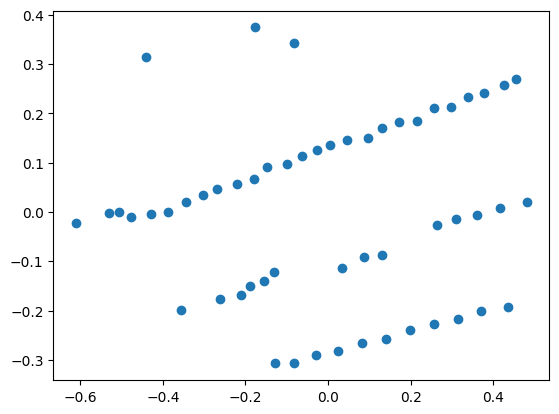

In [ ]:
xx, yy = trainer.state_pool.states[3][:,:2].T
plt.scatter(xx, yy)

In [ ]:
# load model
# steps = 125

# trainer = Trainer.load_model("model3.pt")
# rollout = trainer.rollout(steps = steps)

# to_display = []
# to_display.append(displayer.display_loss())
# # to_display.append(displayer.display_rollout_as_static(rollout))
# to_display.append(displayer.display_rollout_image(rollout))
# to_display.append(displayer.display_rollout_image_gauss(rollout))
# to_display.append(displayer.display_rollout_image_gauss_difference(rollout))
# # to_display.append(displayer.display_rollout_3d(rollout))

# display(displayer.display_multiple(to_display))


In [ ]:
x, y, a ,b = rollout[0].T

plt.scatter(x, y, s=20)

ValueError: not enough values to unpack (expected 4, got 3)

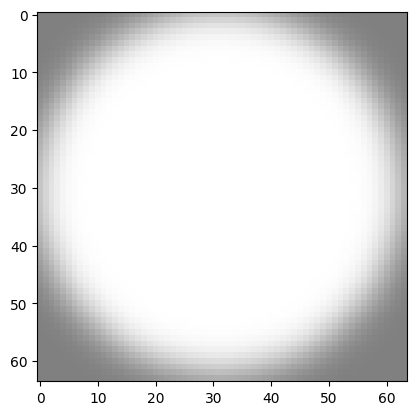

In [ ]:
plt.imshow(img_grid.cpu().numpy(), cmap='gray', alpha=0.5)

In [ ]:
# see all trainable parameters
for name, param in trainer.particle_system.named_parameters():
    if param.requires_grad:
        print(name,)

message_conv.nn.0.weight
message_conv.nn.0.bias
message_conv.nn.2.weight
message_conv.nn.2.bias
message_conv.lin.0.weight
message_conv.lin.0.bias
message_conv.lin.2.weight
message_conv.lin.2.bias
message_to_output_layer.weight
message_to_output_layer.bias
